# 04 — Training
**Resume Classification — Deep Learning Project**

Fine-tuning Longformer untuk klasifikasi 9 kategori resume.

---
**Input  :** `data/processed/train_dataset.pkl`, `val_dataset.pkl`, `label_encoder.pkl`  
**Output :** `models/checkpoint/epoch_N/`, `models/final/`

---
**Environment:** GPU Lokal — RTX 3050 12GB  
**Model:** `allenai/longformer-base-4096`

## 1. Setup & Import Library

In [1]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from transformers import (
    LongformerForSequenceClassification,
    get_linear_schedule_with_warmup,
)
from torch.optim import AdamW
from sklearn.metrics import f1_score, accuracy_score
from tqdm import tqdm

# ============================================================
# KONFIGURASI — sesuaikan jika perlu
# ============================================================
MODEL_NAME          = 'distilbert-base-uncased'
NUM_LABELS          = 9
MAX_LENGTH          = 512     # Dikurangi dari 4096 → aman di 12GB VRAM
                               # Naikkan ke 4096 jika tidak OOM
BATCH_SIZE          = 2       # Longformer besar, batch kecil dulu
GRAD_ACCUM_STEPS    = 8       # Simulasi batch size efektif = 2 x 8 = 16
EPOCHS              = 5
LEARNING_RATE       = 2e-5
WARMUP_RATIO        = 0.1     # 10% pertama dari total steps untuk warmup
MAX_GRAD_NORM       = 1.0     # Gradient clipping
RANDOM_STATE        = 42

PROCESSED_DIR       = '../data/processed/'
CHECKPOINT_DIR      = '../models/checkpoint/'
FINAL_DIR           = '../models/final/'

os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(FINAL_DIR, exist_ok=True)

# Seed untuk reproducibility
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device          : {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU             : {torch.cuda.get_device_name(0)}')
    print(f'VRAM total      : {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB')
print(f'Batch size      : {BATCH_SIZE} (efektif {BATCH_SIZE * GRAD_ACCUM_STEPS} dengan grad accum)')
print(f'Max length      : {MAX_LENGTH} token')

C:\Users\ASUS\AppData\Roaming\Python\Python310\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device          : cuda
GPU             : NVIDIA GeForce RTX 3050 Laptop GPU
VRAM total      : 4.0 GB
Batch size      : 2 (efektif 16 dengan grad accum)
Max length      : 512 token


In [2]:

# ============================================================
# RESUME DATASET CLASS
# ============================================================
class ResumeDataset(torch.utils.data.Dataset):
    """
    PyTorch Dataset untuk resume classification.
    Kompatibel dengan BERT, DistilBERT, dan Longformer.
    """

    def __init__(self, dataframe, tokenizer, max_length):
        self.texts      = dataframe['clean_text'].tolist() if hasattr(dataframe, 'clean_text') else [item['text'] for item in dataframe]
        self.labels     = dataframe['label'].tolist() if hasattr(dataframe, 'label') else [item['label'] for item in dataframe]
        self.tokenizer  = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text  = self.texts[idx]
        label = self.labels[idx]

        encoding = self.tokenizer(
            text,
            max_length      = self.max_length,
            padding         = 'max_length',
            truncation      = True,
            return_tensors  = 'pt',
        )

        item = {
            'input_ids'      : encoding['input_ids'].squeeze(0),
            'attention_mask' : encoding['attention_mask'].squeeze(0),
            'label'          : torch.tensor(label, dtype=torch.long),
        }

        # Longformer butuh global_attention_mask pada token [CLS]
        if 'longformer' in self.tokenizer.name_or_path.lower():
            global_attention_mask = torch.zeros_like(item['input_ids'])
            global_attention_mask[0] = 1   # aktifkan global attention di [CLS]
            item['global_attention_mask'] = global_attention_mask

        return item


> **Catatan VRAM RTX 3050 12GB:**
> - `MAX_LENGTH=2048`, `BATCH_SIZE=2` → aman (~10GB VRAM)
> - `MAX_LENGTH=4096`, `BATCH_SIZE=1` → bisa dicoba, mepet
> - Jika muncul `CUDA out of memory` → turunkan `MAX_LENGTH` ke `1024`
> - `GRAD_ACCUM_STEPS=8` membuat batch efektif = 16, cukup untuk training stabil

## 2. Load Dataset & DataLoader

In [3]:
# Load dataset dari hasil tokenisasi
with open(os.path.join(PROCESSED_DIR, 'train_dataset.pkl'), 'rb') as f:
    train_dataset = pickle.load(f)

with open(os.path.join(PROCESSED_DIR, 'val_dataset.pkl'), 'rb') as f:
    val_dataset = pickle.load(f)

with open(os.path.join(PROCESSED_DIR, 'label_encoder.pkl'), 'rb') as f:
    le = pickle.load(f)

print(f'Train : {len(train_dataset):,} sampel')
print(f'Val   : {len(val_dataset):,} sampel')
print(f'Kelas : {le.classes_.tolist()}')

Train : 4,018 sampel
Val   : 861 sampel
Kelas : ['Business Analyst (BA) Resumes', 'Business Intelligence, Business Object Resumes', 'Datawarehousing, ETL, Informatica Resumes', 'Java Developers/Architects Resumes', 'Network and Systems Administrators Resumes', 'Project Manager Resumes', 'Recruiter Resumes', 'SQL Developers Resumes', 'Web Developer Resumes']


In [4]:
train_loader = DataLoader(
    train_dataset,
    batch_size  = BATCH_SIZE,
    shuffle     = True,
    num_workers = 0,
    pin_memory  = True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size  = BATCH_SIZE,
    shuffle     = False,
    num_workers = 0,
    pin_memory  = True,
)

print(f'Train batches : {len(train_loader)}')
print(f'Val batches   : {len(val_loader)}')

Train batches : 2009
Val batches   : 431


## 3. Load Model

In [6]:
from transformers import AutoModelForSequenceClassification, LongformerForSequenceClassification

# Load model — handle model-specific kwargs safely
model_name_lower = MODEL_NAME.lower()
if 'longformer' in model_name_lower:
    model = LongformerForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels              = NUM_LABELS,
        attention_window        = 512,   # local attention window (Longformer-only)
        ignore_mismatched_sizes = True,
    )
else:
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels              = NUM_LABELS,
        ignore_mismatched_sizes = True,
    )

model = model.to(DEVICE)

# Hitung total parameter
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total parameter     : {total_params:,}')
print(f'Trainable parameter : {trainable_params:,}')

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 9158.07it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total parameter     : 66,960,393
Trainable parameter : 66,960,393


## 4. Optimizer & Scheduler

In [7]:
# AdamW dengan weight decay berbeda untuk bias dan layer norm
no_decay = ['bias', 'LayerNorm.weight']
optimizer_grouped_parameters = [
    {
        'params'       : [p for n, p in model.named_parameters() if not any(nd in n for nd in no_decay)],
        'weight_decay' : 0.01,
    },
    {
        'params'       : [p for n, p in model.named_parameters() if any(nd in n for nd in no_decay)],
        'weight_decay' : 0.0,
    },
]

optimizer = AdamW(optimizer_grouped_parameters, lr=LEARNING_RATE)

# Total steps & warmup
total_steps  = (len(train_loader) // GRAD_ACCUM_STEPS) * EPOCHS
warmup_steps = int(total_steps * WARMUP_RATIO)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps   = warmup_steps,
    num_training_steps = total_steps,
)

print(f'Total training steps : {total_steps}')
print(f'Warmup steps         : {warmup_steps}')
print(f'Learning rate        : {LEARNING_RATE}')

Total training steps : 1255
Warmup steps         : 125
Learning rate        : 2e-05


## 5. Fungsi Evaluasi

In [8]:
def evaluate(model, loader, device):
    """Jalankan evaluasi pada val/test loader, return loss, accuracy, macro F1."""
    model.eval()
    total_loss  = 0
    all_preds   = []
    all_labels  = []
    criterion   = nn.CrossEntropyLoss()

    with torch.no_grad():
        for batch in tqdm(loader, desc='Evaluating', leave=False):
            input_ids             = batch['input_ids'].to(device)
            attention_mask        = batch['attention_mask'].to(device)
            labels                = batch['label'].to(device)
            global_attention_mask = batch.get('global_attention_mask')

            kwargs = dict(
                input_ids      = input_ids,
                attention_mask = attention_mask,
            )
            if global_attention_mask is not None:
                kwargs['global_attention_mask'] = global_attention_mask.to(device)

            outputs = model(**kwargs)
            logits  = outputs.logits
            loss    = criterion(logits, labels)

            total_loss += loss.item()
            preds = torch.argmax(logits, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader)
    accuracy = accuracy_score(all_labels, all_preds)
    f1       = f1_score(all_labels, all_preds, average='macro')

    return avg_loss, accuracy, f1


print('Fungsi evaluate siap.')

Fungsi evaluate siap.


## 6. Training Loop

In [9]:
criterion    = nn.CrossEntropyLoss()
history      = []          # simpan metrik tiap epoch
best_val_f1  = 0.0
best_epoch   = 0

print(f'Mulai training — {EPOCHS} epoch')
print('=' * 60)

for epoch in range(1, EPOCHS + 1):

    # ── TRAIN ──────────────────────────────────────────────
    model.train()
    train_loss   = 0
    optimizer.zero_grad()

    loop = tqdm(enumerate(train_loader), total=len(train_loader),
                desc=f'Epoch {epoch}/{EPOCHS} [Train]')

    for step, batch in loop:
        input_ids             = batch['input_ids'].to(DEVICE)
        attention_mask        = batch['attention_mask'].to(DEVICE)
        labels                = batch['label'].to(DEVICE)
        global_attention_mask = batch.get('global_attention_mask')

        kwargs = dict(
            input_ids      = input_ids,
            attention_mask = attention_mask,
        )
        if global_attention_mask is not None:
            kwargs['global_attention_mask'] = global_attention_mask.to(DEVICE)

        outputs = model(**kwargs)
        loss    = criterion(outputs.logits, labels)

        # Gradient accumulation
        loss = loss / GRAD_ACCUM_STEPS
        loss.backward()

        train_loss += loss.item() * GRAD_ACCUM_STEPS

        if (step + 1) % GRAD_ACCUM_STEPS == 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad()

        # Update progress bar
        loop.set_postfix(loss=f'{train_loss/(step+1):.4f}',
                         lr=f'{scheduler.get_last_lr()[0]:.2e}')

    avg_train_loss = train_loss / len(train_loader)

    # ── VALIDASI ───────────────────────────────────────────
    val_loss, val_acc, val_f1 = evaluate(model, val_loader, DEVICE)

    # ── LOG ────────────────────────────────────────────────
    print(f'\nEpoch {epoch}/{EPOCHS}')
    print(f'  Train Loss : {avg_train_loss:.4f}')
    print(f'  Val Loss   : {val_loss:.4f}')
    print(f'  Val Acc    : {val_acc*100:.2f}%')
    print(f'  Val F1     : {val_f1:.4f}')

    history.append({
        'epoch'      : epoch,
        'train_loss' : avg_train_loss,
        'val_loss'   : val_loss,
        'val_acc'    : val_acc,
        'val_f1'     : val_f1,
    })

    # ── CHECKPOINT TIAP EPOCH ──────────────────────────────
    ckpt_path = os.path.join(CHECKPOINT_DIR, f'epoch_{epoch}')
    model.save_pretrained(ckpt_path)
    print(f'  Checkpoint disimpan ke: {ckpt_path}')

    # ── SIMPAN MODEL TERBAIK ───────────────────────────────
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_epoch  = epoch
        model.save_pretrained(FINAL_DIR)
        print(f'  ★ Model terbaik diperbarui! (Val F1: {best_val_f1:.4f})')

    print()

print('=' * 60)
print(f'Training selesai!')
print(f'Model terbaik : Epoch {best_epoch} (Val F1 = {best_val_f1:.4f})')
print(f'Disimpan di   : {FINAL_DIR}')

Mulai training — 5 epoch


Epoch 1/5 [Train]: 100%|██████████| 2009/2009 [04:30<00:00,  7.43it/s, loss=1.5196, lr=1.78e-05]



Epoch 1/5
  Train Loss : 1.5196
  Val Loss   : 0.6904
  Val Acc    : 79.09%
  Val F1     : 0.7281


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  3.24it/s]


  Checkpoint disimpan ke: ../models/checkpoint/epoch_1


...


Epoch 5/5
  Train Loss : 0.3193
  Val Loss   : 0.4942
  Val Acc    : 86.06%
  Val F1     : 0.8449


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  3.26it/s]


  Checkpoint disimpan ke: ../models/checkpoint/epoch_5


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.36it/s]

  ★ Model terbaik diperbarui! (Val F1: 0.8449)

Training selesai!
Model terbaik : Epoch 5 (Val F1 = 0.8449)
Disimpan di   : ../models/final/


## 7. Visualisasi Training History

In [10]:
history_df = pd.DataFrame(history)
print(history_df.to_string(index=False))

 epoch  train_loss  val_loss  val_acc   val_f1
     1    1.519556  0.690429 0.790941 0.728080
     2    0.598673  0.585948 0.825784 0.781470
     3    0.454256  0.504071 0.852497 0.828617
     4    0.375162  0.498113 0.858304 0.840590
     5    0.319256  0.494245 0.860627 0.844902


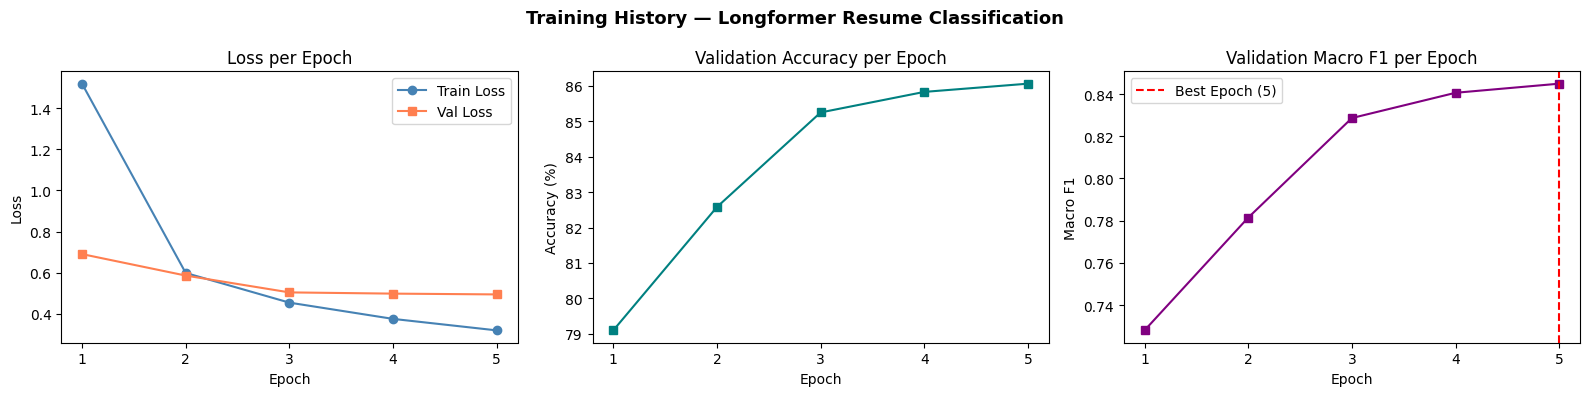

Grafik disimpan ke: data/training_history.png


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Loss
axes[0].plot(history_df['epoch'], history_df['train_loss'], 'o-', label='Train Loss', color='steelblue')
axes[0].plot(history_df['epoch'], history_df['val_loss'],   's-', label='Val Loss',   color='coral')
axes[0].set_title('Loss per Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].set_xticks(history_df['epoch'])

# Accuracy
axes[1].plot(history_df['epoch'], history_df['val_acc'] * 100, 's-', color='teal')
axes[1].set_title('Validation Accuracy per Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_xticks(history_df['epoch'])

# F1
axes[2].plot(history_df['epoch'], history_df['val_f1'], 's-', color='purple')
axes[2].axvline(best_epoch, color='red', linestyle='--', label=f'Best Epoch ({best_epoch})')
axes[2].set_title('Validation Macro F1 per Epoch')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Macro F1')
axes[2].legend()
axes[2].set_xticks(history_df['epoch'])

plt.suptitle('Training History — Longformer Resume Classification', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/training_history.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grafik disimpan ke: data/training_history.png')

## 8. Simpan History & Konfigurasi

In [12]:
import json

# Simpan history ke JSON
history_path = os.path.join(FINAL_DIR, 'training_history.json')
with open(history_path, 'w') as f:
    json.dump(history, f, indent=2)

# Simpan konfigurasi training
train_config = {
    'model_name'       : MODEL_NAME,
    'num_labels'       : NUM_LABELS,
    'max_length'       : MAX_LENGTH,
    'batch_size'       : BATCH_SIZE,
    'grad_accum_steps' : GRAD_ACCUM_STEPS,
    'effective_batch'  : BATCH_SIZE * GRAD_ACCUM_STEPS,
    'epochs'           : EPOCHS,
    'learning_rate'    : LEARNING_RATE,
    'best_epoch'       : best_epoch,
    'best_val_f1'      : best_val_f1,
}
config_path = os.path.join(FINAL_DIR, 'train_config.json')
with open(config_path, 'w') as f:
    json.dump(train_config, f, indent=2)

# Simpan juga label encoder ke folder final
with open(os.path.join(FINAL_DIR, 'label_encoder.pkl'), 'wb') as f:
    pickle.dump(le, f)

print('File tersimpan di models/final/')
for fname in os.listdir(FINAL_DIR):
    fpath = os.path.join(FINAL_DIR, fname)
    if os.path.isfile(fpath):
        size = os.path.getsize(fpath) / (1024*1024)
        print(f'  {fname:40s} ({size:.1f} MB)')

File tersimpan di models/final/
  config.json                              (0.0 MB)
  label_encoder.pkl                        (0.0 MB)
  model.safetensors                        (255.4 MB)
  training_history.json                    (0.0 MB)
  train_config.json                        (0.0 MB)


## 9. Cek Penggunaan VRAM

In [13]:
if DEVICE.type == 'cuda':
    allocated = torch.cuda.max_memory_allocated(0) / 1024**3
    reserved  = torch.cuda.max_memory_reserved(0) / 1024**3
    total     = torch.cuda.get_device_properties(0).total_memory / 1024**3
    print(f'VRAM dipakai (peak) : {allocated:.2f} GB')
    print(f'VRAM reserved       : {reserved:.2f} GB')
    print(f'VRAM total          : {total:.2f} GB')
    print(f'Sisa VRAM           : {total - reserved:.2f} GB')
else:
    print('Tidak ada GPU — training berjalan di CPU')

VRAM dipakai (peak) : 1.37 GB
VRAM reserved       : 1.42 GB
VRAM total          : 4.00 GB
Sisa VRAM           : 2.58 GB


## 10. Ringkasan

In [14]:
print('=' * 60)
print('RINGKASAN TRAINING')
print('=' * 60)
print(f"""
KONFIGURASI
  Model          : {MODEL_NAME}
  Max length     : {MAX_LENGTH} token
  Batch efektif  : {BATCH_SIZE} x {GRAD_ACCUM_STEPS} = {BATCH_SIZE*GRAD_ACCUM_STEPS}
  Epoch          : {EPOCHS}
  Learning rate  : {LEARNING_RATE}

HASIL
  Best epoch     : {best_epoch}
  Best Val F1    : {best_val_f1:.4f}
  Best Val Acc   : {history_df[history_df.epoch==best_epoch]['val_acc'].values[0]*100:.2f}%

OUTPUT
  models/final/              ← model terbaik
  models/checkpoint/         ← semua checkpoint per epoch
  models/final/train_config.json
  models/final/label_encoder.pkl
""")
print('=' * 60)
print('Lanjut ke: 05_evaluasi.ipynb')

RINGKASAN TRAINING

KONFIGURASI
  Model          : distilbert-base-uncased
  Max length     : 512 token
  Batch efektif  : 2 x 8 = 16
  Epoch          : 5
  Learning rate  : 2e-05

HASIL
  Best epoch     : 5
  Best Val F1    : 0.8449
  Best Val Acc   : 86.06%

OUTPUT
  models/final/              ← model terbaik
  models/checkpoint/         ← semua checkpoint per epoch
  models/final/train_config.json
  models/final/label_encoder.pkl

Lanjut ke: 05_evaluasi.ipynb


---
**Notebook ini selesai.** Lanjut ke `05_evaluasi.ipynb` untuk analisis mendalam performa model di test set.